# Task 1 - Part 2 :


Non-linearity occurs when the true relationship between the predictors and the response is not linear, meaning a straight line is a poor approximation of the data. This matters because if the relationship is non-linear, all predictions and inferences from the model are potentially invalid. The primary way to detect this is through residual plots, plotting residuals against fitted values. If the relationship were truly linear, you'd expect no noticeable pattern; a curve or U-shape in the residuals signals non-linearity. The common fix is to apply a non-linear transformation to the predictors or response, such as log(X), square root of X, or X squared, which can sometimes linearize the relationship.

For non-constant variance of error terms the assumption of linear regression model is that the error terms have a constant variance, the variances of the error terms are non-constant. The error terms may increase with the value of the response, the non-constant variance can be indentified in the error or heteroscedasticity from the presend of a funnel shape in the residual plots. The solution for this would be a transformation in the response variable (Y) such as logY or square root of Y. Question: is the transformation done before or after all observations? The transformation is done before model fitting. questions: When should the transformation occur if the points aren't much different when comparing the before and after transformation? It is to fit the data between 0-1, to show no sign of heterdesticity. 

High leverage points:  Observations with high leverage have an unusual value of Xi. It is important to identify high leverage observations as they have more substantial impact on the least square line. They tend to have a sizable impact on the estimated regression line. This is a concern because any problems with these points may invalidate the entire fit. This is where we would use a leverage statistic in order to quantify an observation leverage. If the point also has a large residual a solution would be to remove those points as they may also be associated to a high leverage point which would be a dangerous combination.
question: what is the difference between an outlier and a high leverage point? An outlier is an observation with an unusual response value Y given its predictor value X, it has a large residual. A high leverage point has an unusual X value relative to the other observations, whether Y fits the model well. The danger is that high leverage points can pull the regression line toward themselves, masking their own large residual on a standard residual plot, which is why studentized residuals are recommended for outlier detection. The two can overlap: a point that is both an outlier and high leverage is called an influential point and poses the greatest risk to the model fit - this is the dangerous combination mentioned in the book.




# Part 3
## Code from claude 

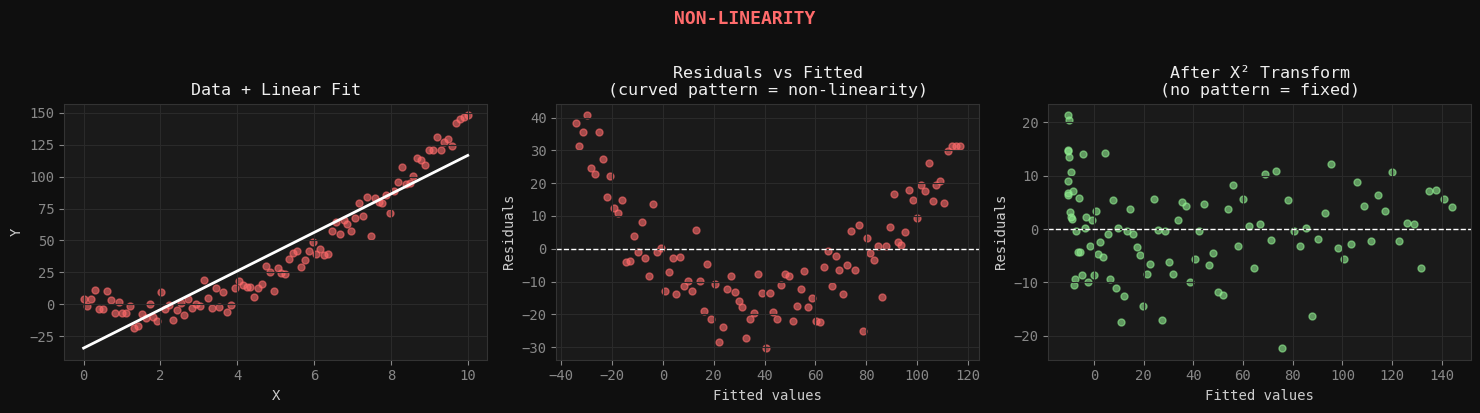

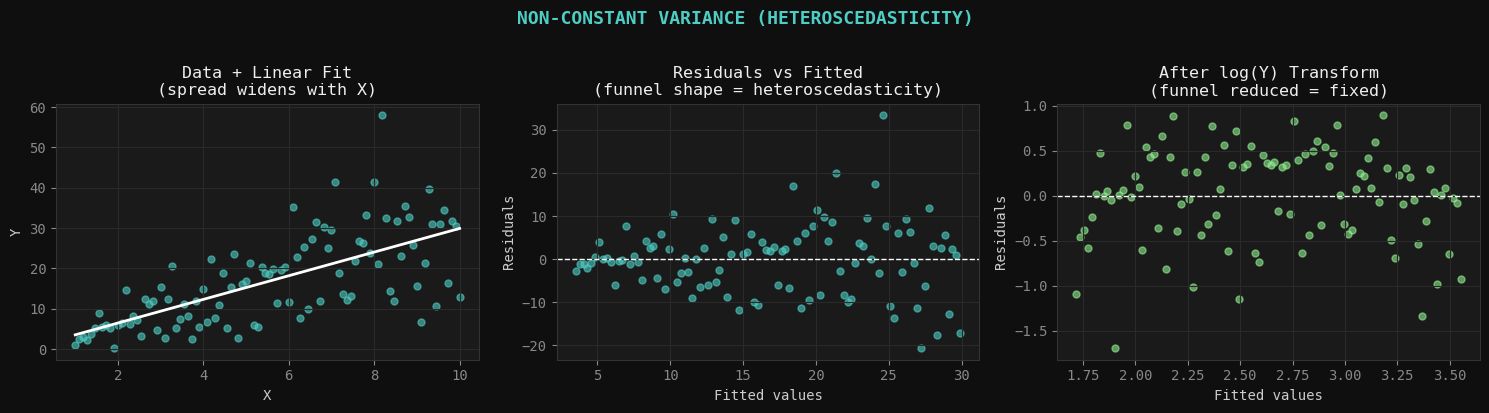

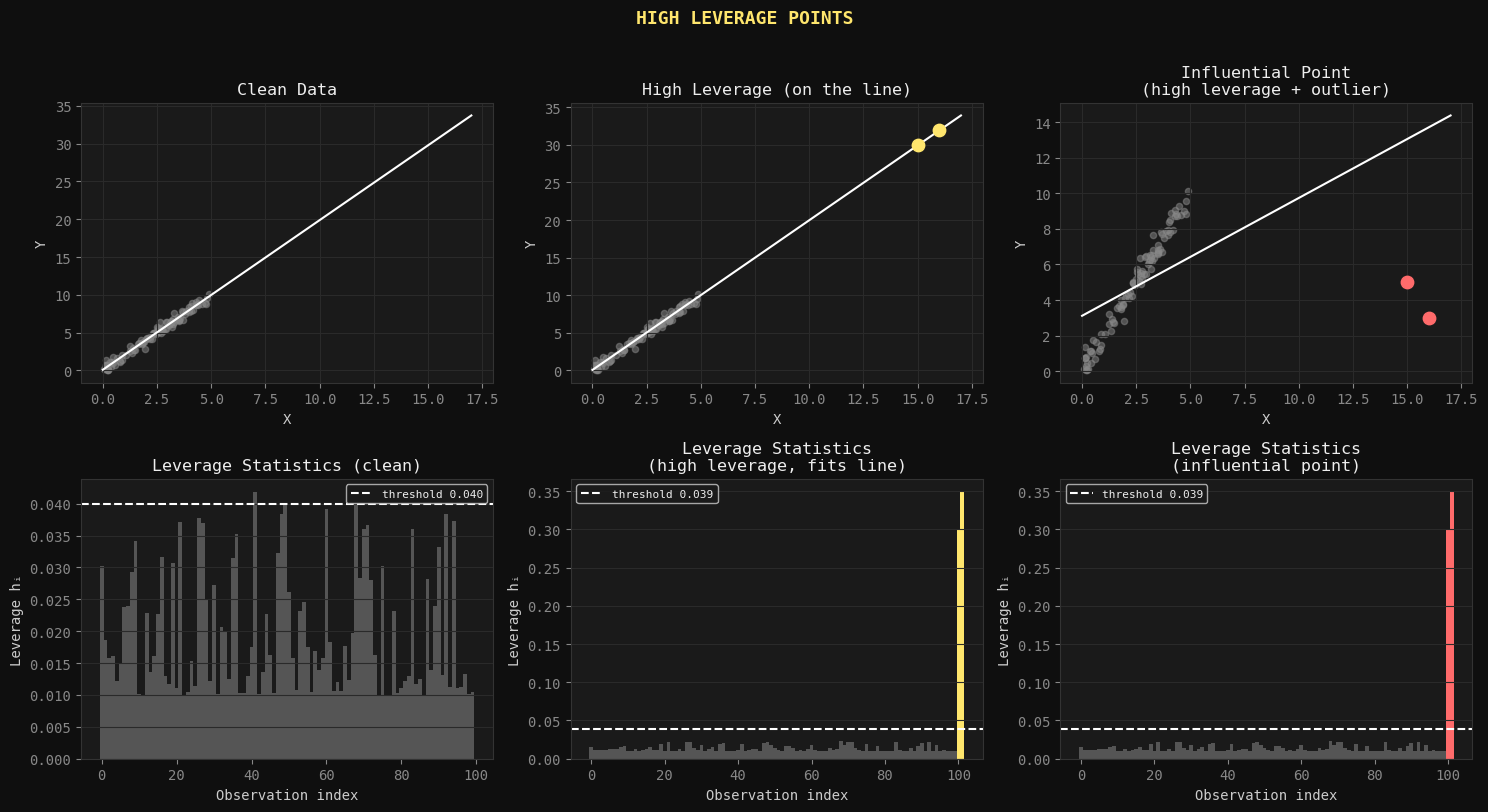

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression

np.random.seed(42)
n = 100

plt.rcParams.update({"figure.facecolor": "#0f0f0f", "axes.facecolor": "#1a1a1a",
                     "axes.edgecolor": "#333", "axes.labelcolor": "#ccc",
                     "xtick.color": "#888", "ytick.color": "#888",
                     "grid.color": "#2a2a2a", "text.color": "#eee",
                     "font.family": "monospace"})

ACCENT = ["#ff6b6b", "#4ecdc4", "#ffe66d"]


def fitted_and_residuals(X, y):
    model = LinearRegression().fit(X.reshape(-1, 1), y)
    y_hat = model.predict(X.reshape(-1, 1))
    resid = y - y_hat
    return y_hat, resid, model


# 1. NON-LINEARITY

X1 = np.linspace(0, 10, n)
y1 = 2 * X1**2 - 5 * X1 + np.random.normal(0, 8, n)   

y1_hat, resid1, model1 = fitted_and_residuals(X1, y1)

# Transform
X1_sq = X1 ** 2
y1_hat_fix, resid1_fix, _ = fitted_and_residuals(X1_sq, y1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("NON-LINEARITY", color=ACCENT[0], fontsize=13, fontweight="bold", y=1.02)

# Raw data + linear fit
axes[0].scatter(X1, y1, alpha=0.6, color=ACCENT[0], s=25)
axes[0].plot(X1, y1_hat, color="white", linewidth=2)
axes[0].set(title="Data + Linear Fit", xlabel="X", ylabel="Y")

# Residual plot 
axes[1].axhline(0, color="white", linewidth=1, linestyle="--")
axes[1].scatter(y1_hat, resid1, alpha=0.6, color=ACCENT[0], s=25)
axes[1].set(title="Residuals vs Fitted\n(curved pattern = non-linearity)",
            xlabel="Fitted values", ylabel="Residuals")

axes[2].axhline(0, color="white", linewidth=1, linestyle="--")
axes[2].scatter(y1_hat_fix, resid1_fix, alpha=0.6, color="#90ee90", s=25)
axes[2].set(title="After X² Transform\n(no pattern = fixed)", xlabel="Fitted values", ylabel="Residuals")

for ax in axes:
    ax.grid(True)
plt.tight_layout()



# 2. NON-CONSTANT VARIANCE (HETEROSCEDASTICITY)
X2 = np.linspace(1, 10, n)
y2 = 3 * X2 + np.random.normal(0, X2 * 1.5, n)   # variance grows with X

y2_hat, resid2, _ = fitted_and_residuals(X2, y2)

# Fix: log-transform Y
y2_log = np.log(np.abs(y2) + 1)                   # +1 avoids log(0)
y2_hat_log, resid2_log, _ = fitted_and_residuals(X2, y2_log)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("NON-CONSTANT VARIANCE (HETEROSCEDASTICITY)", color=ACCENT[1],
             fontsize=13, fontweight="bold", y=1.02)

axes[0].scatter(X2, y2, alpha=0.6, color=ACCENT[1], s=25)
axes[0].plot(X2, y2_hat, color="white", linewidth=2)
axes[0].set(title="Data + Linear Fit\n(spread widens with X)", xlabel="X", ylabel="Y")

axes[1].axhline(0, color="white", linewidth=1, linestyle="--")
axes[1].scatter(y2_hat, resid2, alpha=0.6, color=ACCENT[1], s=25)
axes[1].set(title="Residuals vs Fitted\n(funnel shape = heteroscedasticity)",
            xlabel="Fitted values", ylabel="Residuals")

axes[2].axhline(0, color="white", linewidth=1, linestyle="--")
axes[2].scatter(y2_hat_log, resid2_log, alpha=0.6, color="#90ee90", s=25)
axes[2].set(title="After log(Y) Transform\n(funnel reduced = fixed)",
            xlabel="Fitted values", ylabel="Residuals")

for ax in axes:
    ax.grid(True)
plt.tight_layout()



# 3. HIGH LEVERAGE POINTS
X3 = np.random.uniform(0, 5, n)
y3 = 2 * X3 + np.random.normal(0, 0.5, n)

X3_lev = np.append(X3, [15, 16])
y3_lev = np.append(y3, [30, 32])  

X3_inf = np.append(X3, [15, 16])
y3_inf = np.append(y3, [5, 3])    

y3_hat, resid3, model3 = fitted_and_residuals(X3, y3)
y3_hat_lev, resid3_lev, model3_lev = fitted_and_residuals(X3_lev, y3_lev)
y3_hat_inf, resid3_inf, model3_inf = fitted_and_residuals(X3_inf, y3_inf)


def leverage(X):
    """Hat matrix diagonal (leverage statistic h_i)."""
    Xm = np.column_stack([np.ones(len(X)), X])
    H = Xm @ np.linalg.inv(Xm.T @ Xm) @ Xm.T
    return np.diag(H)


h3 = leverage(X3)
h3_lev = leverage(X3_lev)
h3_inf = leverage(X3_inf)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("HIGH LEVERAGE POINTS", color=ACCENT[2], fontsize=13, fontweight="bold", y=1.01)

x_line = np.linspace(0, 17, 200)

# Row 1: scatter plots
for ax, X, y, y_hat, model, title, color, hi_idx in [
    (axes[0, 0], X3, y3, y3_hat, model3,
     "Clean Data", "#aaa", []),
    (axes[0, 1], X3_lev, y3_lev, y3_hat_lev, model3_lev,
     "High Leverage (on the line)", ACCENT[2], [n, n+1]),
    (axes[0, 2], X3_inf, y3_inf, y3_hat_inf, model3_inf,
     "Influential Point\n(high leverage + outlier)", "#ff6b6b", [n, n+1]),
]:
    mask = np.ones(len(X), dtype=bool)
    mask[hi_idx] = False
    ax.scatter(X[mask], y[mask], alpha=0.5, color="#888", s=20)
    if hi_idx:
        ax.scatter(X[hi_idx], y[hi_idx], color=color, s=80, zorder=5, label="leverage point")
    ax.plot(x_line, model.coef_[0] * x_line + model.intercept_, color="white", linewidth=1.5)
    ax.set(title=title, xlabel="X", ylabel="Y", xlim=(-1, 18))
    ax.grid(True)

# Row 2: leverage statistic plots
threshold = lambda X: 2 * 2 / len(X)   # 2(p+1)/n, p=1

for ax, X, h, title, color, hi_idx in [
    (axes[1, 0], X3, h3, "Leverage Statistics (clean)", "#aaa", []),
    (axes[1, 1], X3_lev, h3_lev, "Leverage Statistics\n(high leverage, fits line)", ACCENT[2], [n, n+1]),
    (axes[1, 2], X3_inf, h3_inf, "Leverage Statistics\n(influential point)", "#ff6b6b", [n, n+1]),
]:
    thresh = threshold(X)
    colors = [color if i in hi_idx else "#555" for i in range(len(X))]
    ax.bar(range(len(X)), h, color=colors, width=1.0)
    ax.axhline(thresh, color="white", linewidth=1.5, linestyle="--", label=f"threshold {thresh:.3f}")
    ax.set(title=title, xlabel="Observation index", ylabel="Leverage hᵢ")
    ax.legend(fontsize=8)
    ax.grid(True, axis="y")

plt.tight_layout()



In the non-linearity, for the first plot with a linear fit, I noticed a non-linear fit where the data is not following the linear fit. When the data is plotted on a residual plot, the U-shape is more apparent, this indates a strong fit for non-linearity data. After the transformation happened the points seem to be more around the fixed on the line, there is no u-shape 

Non-constant variance of error term I could kind of see the funnel shape in the response Y/ Residual plot, where this may be an indication of heterodesticity. After is was transformed the points do appear to have a constant variance, although there is still a sign of non-linear relationship in the data.

High Leverage Points Im not sure what I was expecting, but it wasn't this. I was hoping for something a little more similar to what is on the text book. In the second/ middle plot I was expecting the points to be similar to the plot after on the right. It seems like the leverage statistic was also ran, which I did not mention it to run.

The AI tool I used to generate the plots for part 3 was using claude. I gave it the prompt from the assignment with the three common issues I identified in part 2. It only took one iteration to get the code running. I noticed it wanted to save the plots as a png, as well as store it into a non-existing folder path that I did not give it. Other than that that was the only thing that gave me an error when I pasted it into a code chunk. I also noticed it used a package called `import matplotlib.gridspec as gridspec`.